In [3]:
!pip install torch
!pip install torch-geometric
!pip install networkx
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.2 MB/s eta 0:00:00


In [4]:
import numpy as np
import networkx as nx
import torch

from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import SpectralClustering
from sklearn.metrics import normalized_mutual_info_score

Load CiteSeer Dataset

In [5]:
dataset = Planetoid(root='data', name='Citeseer')

data = dataset[0]

print("Nodes:", data.num_nodes)
print("Edges:", data.num_edges)
print("Features:", data.num_features)

Processing...


Nodes: 3327
Edges: 9104
Features: 3703


Done!


Convert to Network Graph

In [6]:
G = to_networkx(data, to_undirected=True)

print("Graph created successfully")

Graph created successfully


Extract Node Attributes

In [7]:
attributes = data.x.numpy()

print("Attribute matrix shape:", attributes.shape)

Attribute matrix shape: (3327, 3703)


Compute Structural Similarity

In [8]:
n = G.number_of_nodes()

struct_sim = np.zeros((n, n))

for i in range(n):
    neighbors_i = set(G.neighbors(i))

    for j in range(n):
        neighbors_j = set(G.neighbors(j))

        union = neighbors_i | neighbors_j
        intersection = neighbors_i & neighbors_j

        if len(union) > 0:
            struct_sim[i][j] = len(intersection) / len(union)

Compute Attribute Similarity

In [9]:
attr_sim = cosine_similarity(attributes)

Combine Similarities (MASCD Formula)

In [10]:
alpha = 0.5

total_similarity = alpha * struct_sim + (1 - alpha) * attr_sim

Community Detection

In [11]:
num_communities = 6

model = SpectralClustering(
    n_clusters=num_communities,
    affinity='precomputed',
    random_state=42
)

labels = model.fit_predict(total_similarity)

Print Communities

In [12]:
communities = {}

for node, label in enumerate(labels):
    if label not in communities:
        communities[label] = []
    communities[label].append(node)

for c in communities:
    print("Community", c, ":", len(communities[c]), "nodes")

Community 4 : 515 nodes
Community 2 : 604 nodes
Community 3 : 838 nodes
Community 0 : 729 nodes
Community 5 : 639 nodes
Community 1 : 2 nodes


Evaluate with NMI

In [13]:
true_labels = data.y.numpy()

nmi = normalized_mutual_info_score(true_labels, labels)

print("NMI Score:", nmi)

NMI Score: 0.2634456943398965


Compute Modularity

In [14]:
community_list = list(communities.values())

modularity = nx.algorithms.community.quality.modularity(G, community_list)

print("Modularity:", modularity)

Modularity: 0.39036395674587115


Graph

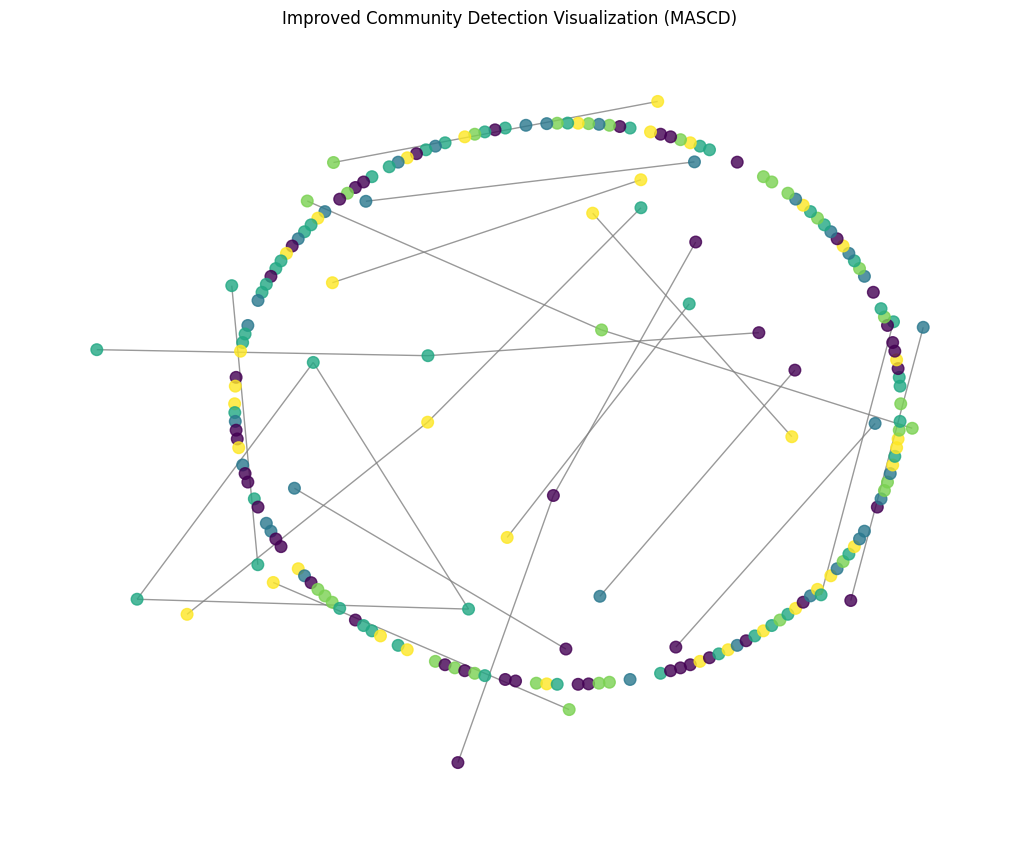

In [19]:
import matplotlib.pyplot as plt

subset_nodes = list(G.nodes())[:200]
subG = G.subgraph(subset_nodes)

pos = nx.kamada_kawai_layout(subG)

plt.figure(figsize=(10,8))

colors = [labels[node] for node in subG.nodes()]

nx.draw(
    subG,
    pos,
    node_color=colors,
    node_size=70,
    edge_color="gray",
    alpha=0.8
)

plt.title("Improved Community Detection Visualization (MASCD)")
plt.show()